In [51]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



In [52]:
log_path = "training_log.txt"

with open(log_path, "r") as f:
    raw_log = f.read()


output_dir = Path("plots/blue_winrate_heatmaps")
output_dir.mkdir(parents=True, exist_ok=True)


In [53]:
pattern = re.compile(
    r"Blue/Red win percantage: (?P<winrate>[\d.]+) \| "
    r"Blue Troops: (?P<blue>\d+) \| "
    r"Red Troops: (?P<red>\d+) \| "
    r"Enemy Type: (?P<enemy>.+)"
)

records = []

for line in raw_log.strip().split("\n"):
    match = pattern.search(line)
    if match:
        records.append({
            "enemy_type": match.group("enemy"),
            "blue_troops": int(match.group("blue")),
            "red_troops": int(match.group("red")),
            "blue_winrate": float(match.group("winrate"))
        })

df = pd.DataFrame(records)
df.info()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   enemy_type    100 non-null    object 
 1   blue_troops   100 non-null    int64  
 2   red_troops    100 non-null    int64  
 3   blue_winrate  100 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ KB


,enemy_type,blue_troops,red_troops,blue_winrate
0,Default Enemy,1,1,0.0
1,Default Enemy,1,2,0.0
2,Default Enemy,1,3,0.0
3,Default Enemy,1,4,0.0
4,Default Enemy,1,5,0.0
...,...,...,...,...
95,NNAI Enemy,5,1,100.0
96,NNAI Enemy,5,2,100.0
97,NNAI Enemy,5,3,100.0
98,NNAI Enemy,5,4,100.0


In [54]:
def build_winrate_table(df, enemy, max_troops=5):
    table = pd.DataFrame(
        np.nan,
        index=range(1, max_troops + 1),
        columns=range(1, max_troops + 1)
    )

    sub = df[df["enemy_type"] == enemy]

    for _, row in sub.iterrows():
        table.loc[row["blue_troops"], row["red_troops"]] = row["blue_winrate"]

    table.index.name = "Blue Troops"
    table.columns.name = "Red Troops"
    return table


In [55]:
enemy_types = df["enemy_type"].unique()

tables = {}
for enemy in enemy_types:
    tables[enemy] = build_winrate_table(df, enemy)
    print(f"\n=== {enemy} ===")
    display(tables[enemy])



=== Default Enemy ===


Red Troops,1,2,3,4,5
Blue Troops,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,54.0,21.0,3.0,0.0,0.0
3,57.0,25.0,14.0,2.0,0.0
4,55.0,49.0,23.0,6.0,2.0
5,77.0,59.0,33.0,12.0,6.0



=== Aggressive Enemy ===


Red Troops,1,2,3,4,5
Blue Troops,,,,,
1,91.0,0.0,0.0,0.0,0.0
2,67.0,17.0,4.0,1.0,0.0
3,73.0,24.0,11.0,3.0,2.0
4,65.0,45.0,25.0,8.0,8.0
5,71.0,70.0,36.0,22.0,10.0



=== Random Enemy ===


Red Troops,1,2,3,4,5
Blue Troops,,,,,
1,52.0,34.0,6.0,1.0,0.0
2,97.0,98.0,99.0,82.0,79.0
3,99.0,100.0,98.0,96.0,87.0
4,99.0,99.0,100.0,98.0,98.0
5,100.0,99.0,97.0,99.0,98.0



=== NNAI Enemy ===


Red Troops,1,2,3,4,5
Blue Troops,,,,,
1,0.0,14.0,0.0,0.0,0.0
2,100.0,100.0,100.0,98.0,92.0
3,100.0,100.0,100.0,100.0,99.0
4,100.0,100.0,100.0,100.0,99.0
5,100.0,100.0,100.0,100.0,100.0


In [56]:
def plot_heatmap(
    table,
    enemy_name,
    cmap="coolwarm",
    save_path=None
):
    plt.figure(figsize=(6, 5))

    plt.imshow(
        table,
        origin="lower",
        cmap=cmap,
        vmin=0,
        vmax=100
    )

    plt.colorbar(label="Blue Win Rate (%)")
    plt.title(f"Blue Win Rate vs {enemy_name}")
    plt.xlabel("Red Troops")
    plt.ylabel("Blue Troops")

    plt.xticks(range(len(table.columns)), table.columns)
    plt.yticks(range(len(table.index)), table.index)

    for i in range(len(table.index)):
        for j in range(len(table.columns)):
            val = table.iloc[i, j]
            if not np.isnan(val):
                plt.text(
                    j, i, f"{val:.0f}",
                    ha="center", va="center",
                    color="white" if val < 60 else "black"
                )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()


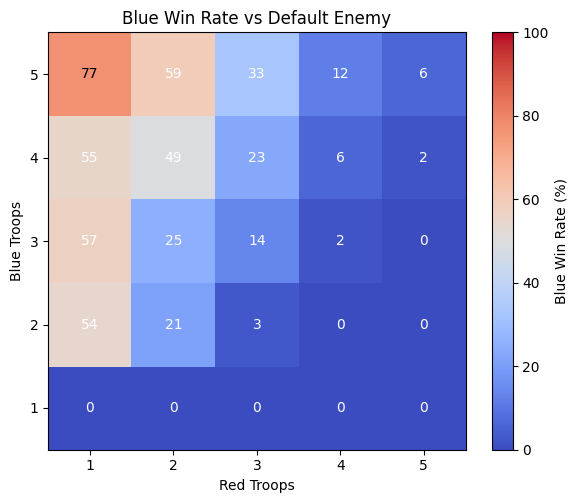

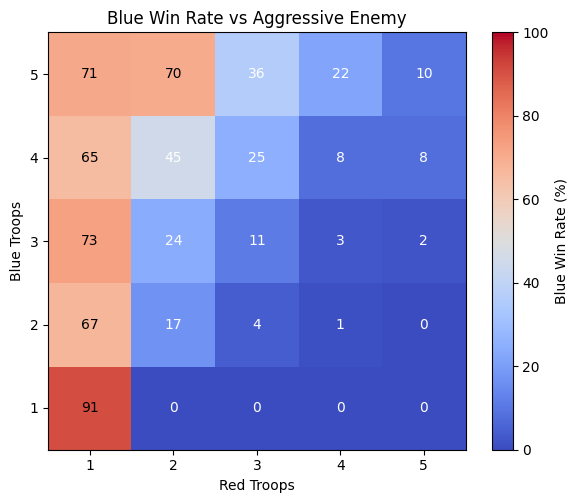

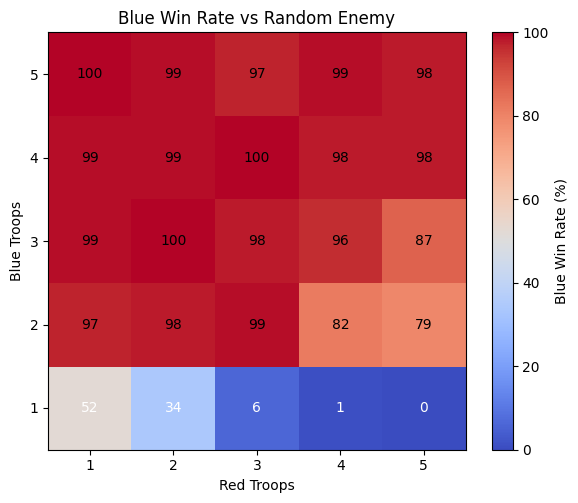

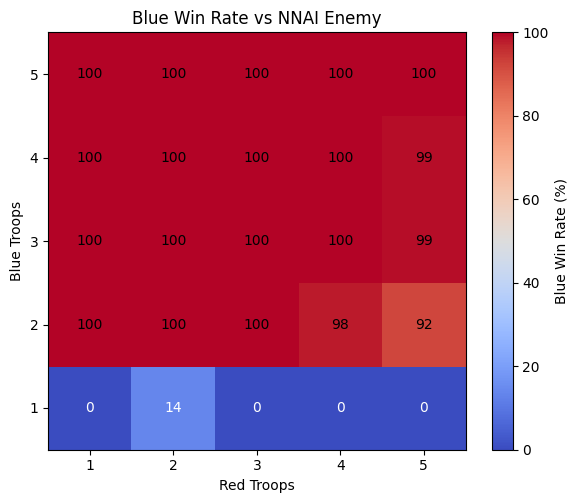

In [57]:
for enemy, table in tables.items():
    safe_name = enemy.lower().replace(" ", "_")
    file_path = output_dir / f"blue_winrate_{safe_name}.png"

    plot_heatmap(
        table,
        enemy_name=enemy,
        save_path=file_path
    )


In [58]:
avg_winrate = (
    df
    .groupby("enemy_type")["blue_winrate"]
    .mean()
    .sort_values(ascending=False)
)

avg_winrate


enemy_type
Random Enemy        80.60
NNAI Enemy          80.08
Aggressive Enemy    26.12
Default Enemy       19.92
Name: blue_winrate, dtype: float64

In [59]:
def plot_average_winrate(avg_winrate, save_path=None):
    plt.figure(figsize=(6, 4))

    plt.bar(
        avg_winrate.index,
        avg_winrate.values
    )

    plt.ylim(0, 100)
    plt.ylabel("Average Blue Win Rate (%)")
    plt.title("Average Blue Win Rate vs Enemy Type")

    plt.xticks(rotation=30, ha="right")

    for i, val in enumerate(avg_winrate.values):
        plt.text(
            i, val + 1,
            f"{val:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()


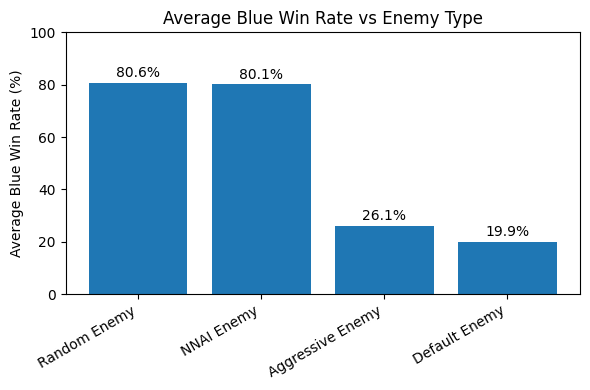

In [60]:
avg_plot_path = output_dir / "average_blue_winrate_per_enemy.png"

plot_average_winrate(
    avg_winrate,
    save_path=avg_plot_path
)
